In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import joblib


In [2]:
df = pd.read_csv('../data/fraudTrain.csv')
df.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

---

Handling missing values

In [4]:
na_count = df.isnull().sum()
na_count[na_count > 0]

Series([], dtype: int64)

---

Handling duplicates

In [5]:
df.duplicated().sum()

0

---

Target distribution

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64
Countplot distribution of 'is_fraud' column:


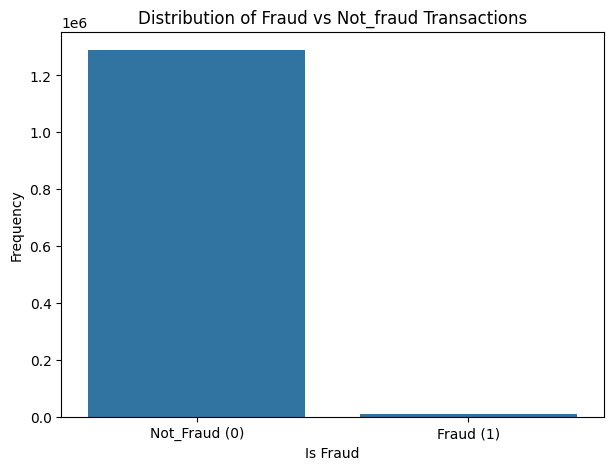

In [6]:
# "is_fraud"column i.e. target variable distribution
print(df["is_fraud"].value_counts(normalize=True))

# Countplot of target variable
print("Countplot distribution of 'is_fraud' column:")
plt.figure(figsize= (7,5))
sns.countplot(x='is_fraud', data=df)
plt.title('Distribution of Fraud vs Not_fraud Transactions')
plt.xlabel("Is Fraud")
plt.ylabel("Frequency")
plt.xticks([0, 1], ['Not_Fraud (0)', 'Fraud (1)'])
plt.show()


Shows significant imbalance in target variables.<br>
Later, May use undersampling or oversampling or hybrid of both

---

Calculate and display descriptive statistics for all numerical columns. Visualize their distributions using histograms and box plots to understand their spread, central tendency, and identify outliers. Provide appropriate legends for all plots.


Descriptive Statistics for Numerical Features (excluding id and target columns):
              amt         zip         lat        long    city_pop  \
count  1296675.00  1296675.00  1296675.00  1296675.00  1296675.00   
mean        70.35    48800.67       38.54      -90.23    88824.44   
std        160.32    26893.22        5.08       13.76   301956.36   
min          1.00     1257.00       20.03     -165.67       23.00   
25%          9.65    26237.00       34.62      -96.80      743.00   
50%         47.52    48174.00       39.35      -87.48     2456.00   
75%         83.14    72042.00       41.94      -80.16    20328.00   
max      28948.90    99783.00       66.69      -67.95  2906700.00   

          unix_time   merch_lat  merch_long  
count  1.296675e+06  1296675.00  1296675.00  
mean   1.349244e+09       38.54      -90.23  
std    1.284128e+07        5.11       13.77  
min    1.325376e+09       19.03     -166.67  
25%    1.338751e+09       34.73      -96.90  
50%    1.349250e+09 

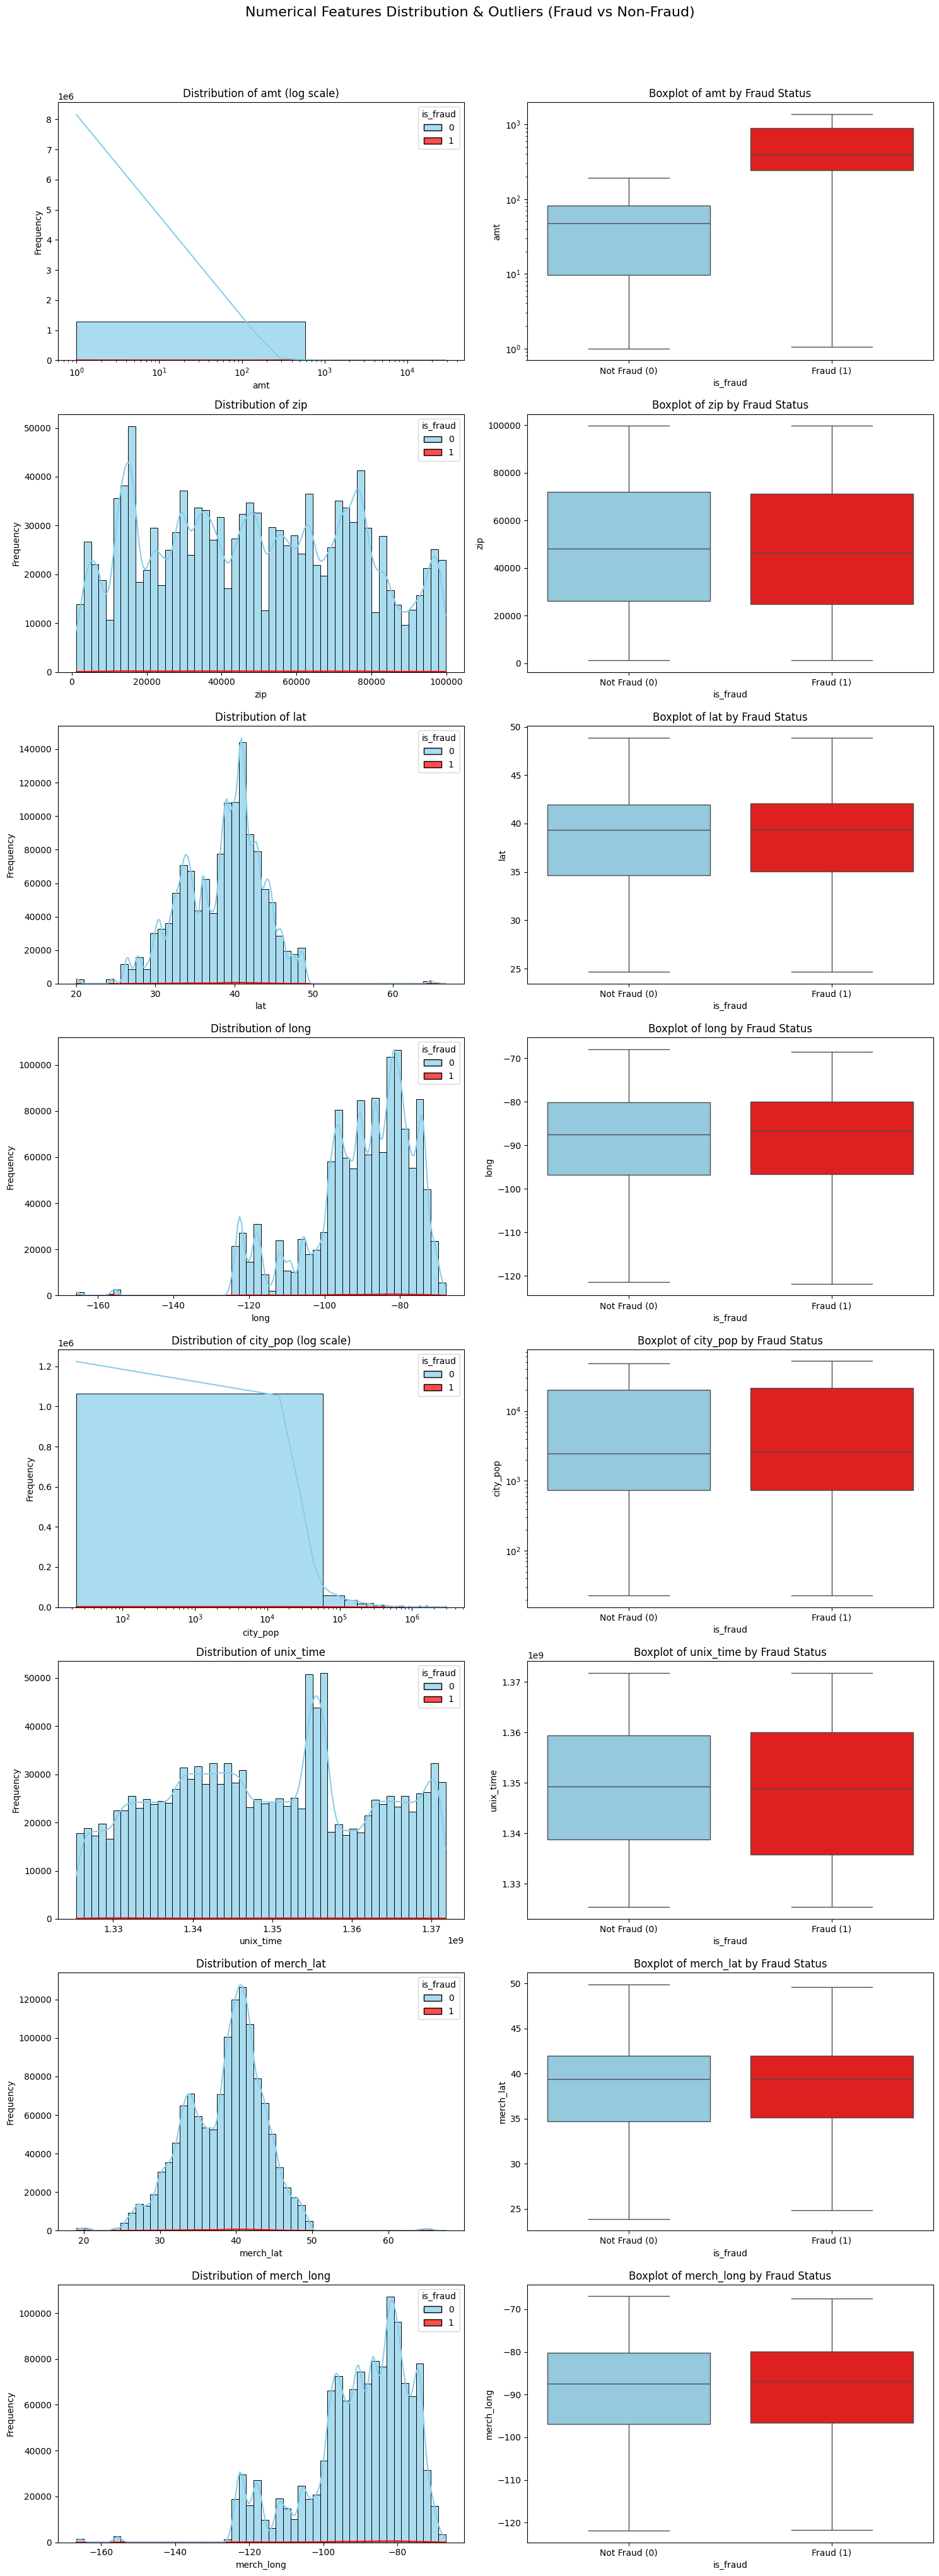

In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'Unnamed: 0', 'cc_num', and 'is_fraud' as specified
exclude_cols = ['Unnamed: 0', 'cc_num', 'is_fraud']
eda_numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

print("\nDescriptive Statistics for Numerical Features (excluding id and target columns):")
print(df[eda_numerical_cols].describe().round(2))

# Define columns that benefit from log scale
log_scale_cols = ['amt', 'city_pop']

n_cols = len(eda_numerical_cols)
fig, axes = plt.subplots(n_cols, 2, figsize=(15, 5 * n_cols))
fig.suptitle('Numerical Features Distribution & Outliers (Fraud vs Non-Fraud)', fontsize=16, y=1.02)

for i, col in enumerate(eda_numerical_cols):
    # Histogram 
    ax_hist = axes[i, 0]
    sns.histplot(data=df, x=col, hue='is_fraud', kde=True, 
                 bins=50, palette=['skyblue', 'red'], alpha=0.7, ax=ax_hist)
    
    if col in log_scale_cols:
        ax_hist.set_xscale('log')
        ax_hist.set_title(f'Distribution of {col} (log scale)')
    else:
        ax_hist.set_title(f'Distribution of {col}')
    
    ax_hist.set_ylabel('Frequency')
    
    # Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=df, x='is_fraud', y=col, palette=['skyblue', 'red'], ax=ax_box, showfliers=False)
    
    if col in log_scale_cols:
        ax_box.set_yscale('log')
    
    ax_box.set_title(f'Boxplot of {col} by Fraud Status')
    ax_box.set_xticklabels(['Not Fraud (0)', 'Fraud (1)'])

plt.tight_layout()
plt.show()

amt and city_pop are extremely right-skewed

---

Distributions of categorical features, specifically 'category' and 'gender', using count plots to understand their frequency and patterns

Distribution of 'category' column:


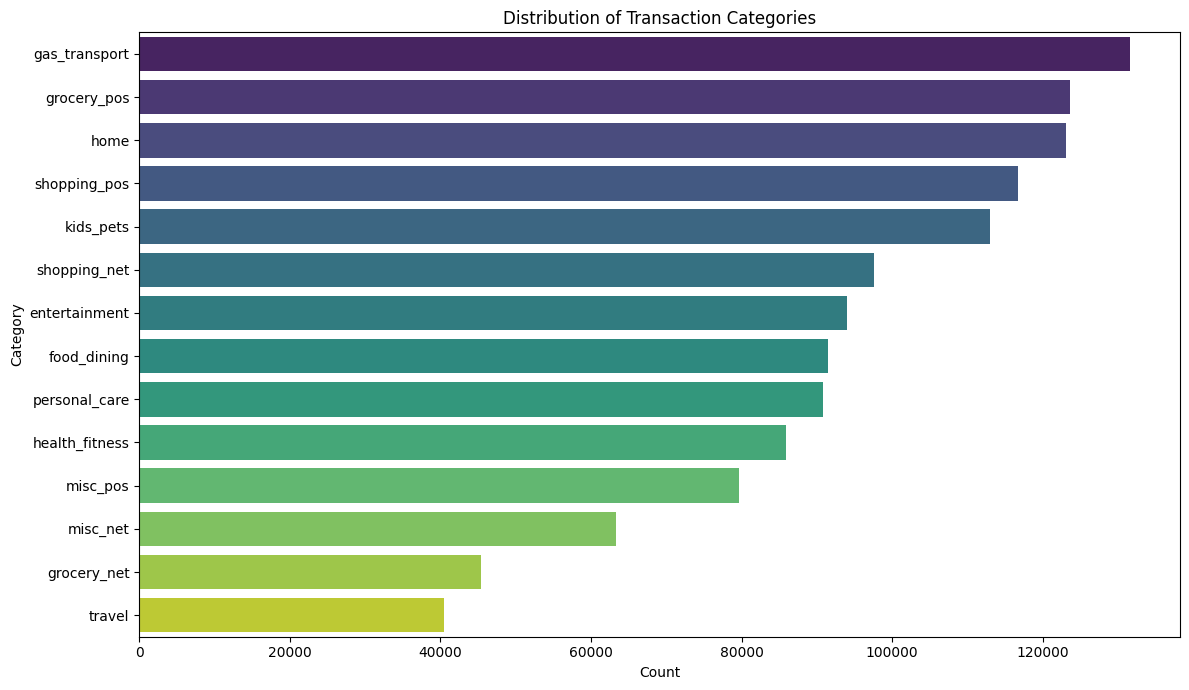


Distribution of 'gender' column:


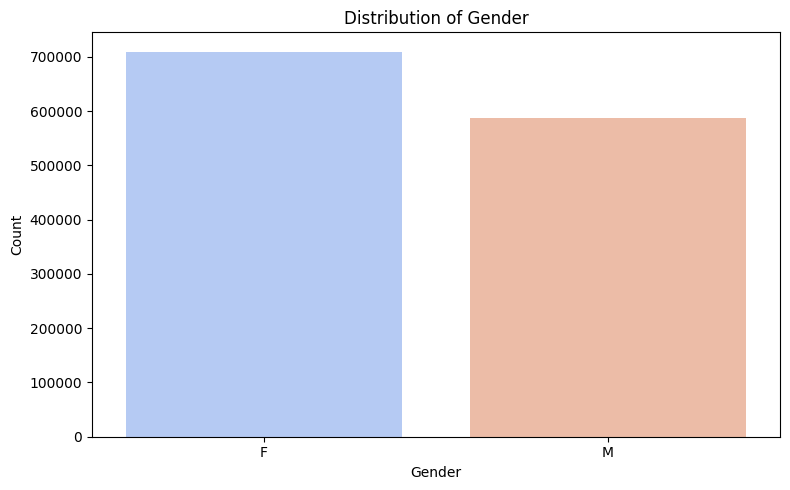

In [8]:
print("Distribution of 'category' column:")
plt.figure(figsize=(12, 7))
sns.countplot(y='category', data=df, palette='viridis', order=df['category'].value_counts().index)
plt.title('Distribution of Transaction Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print("\nDistribution of 'gender' column:")
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', data=df, palette='coolwarm')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

convert the 'trans_date_trans_time' column to datetime objects to enable time-based analysis<br>
To analyze transaction patterns over time, I will extract 'hour of day', 'day of week', and 'month' from the trans_date_trans_time column and add them as new features to the DataFrame.<br>

In [9]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour_of_day'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month

print("DataFrame with new time features:")
df[["trans_date_trans_time","hour_of_day", "day_of_week", "month"]].head()

DataFrame with new time features:


,trans_date_trans_time,hour_of_day,day_of_week,month
0,2019-01-01 00:00:18,0,1,1
1,2019-01-01 00:00:44,0,1,1
2,2019-01-01 00:00:51,0,1,1
3,2019-01-01 00:01:16,0,1,1
4,2019-01-01 00:03:06,0,1,1


Visualize the distribution of total transactions and fraudulent transactions across these time periods to identify any patterns or trends

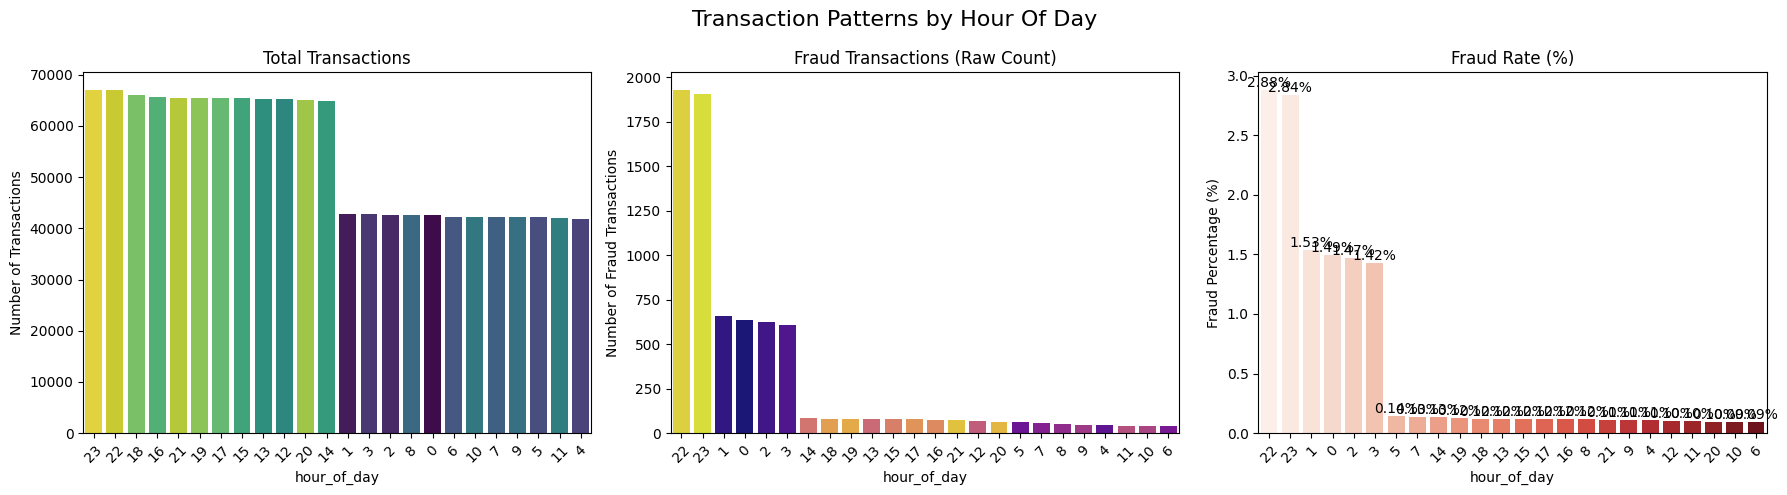

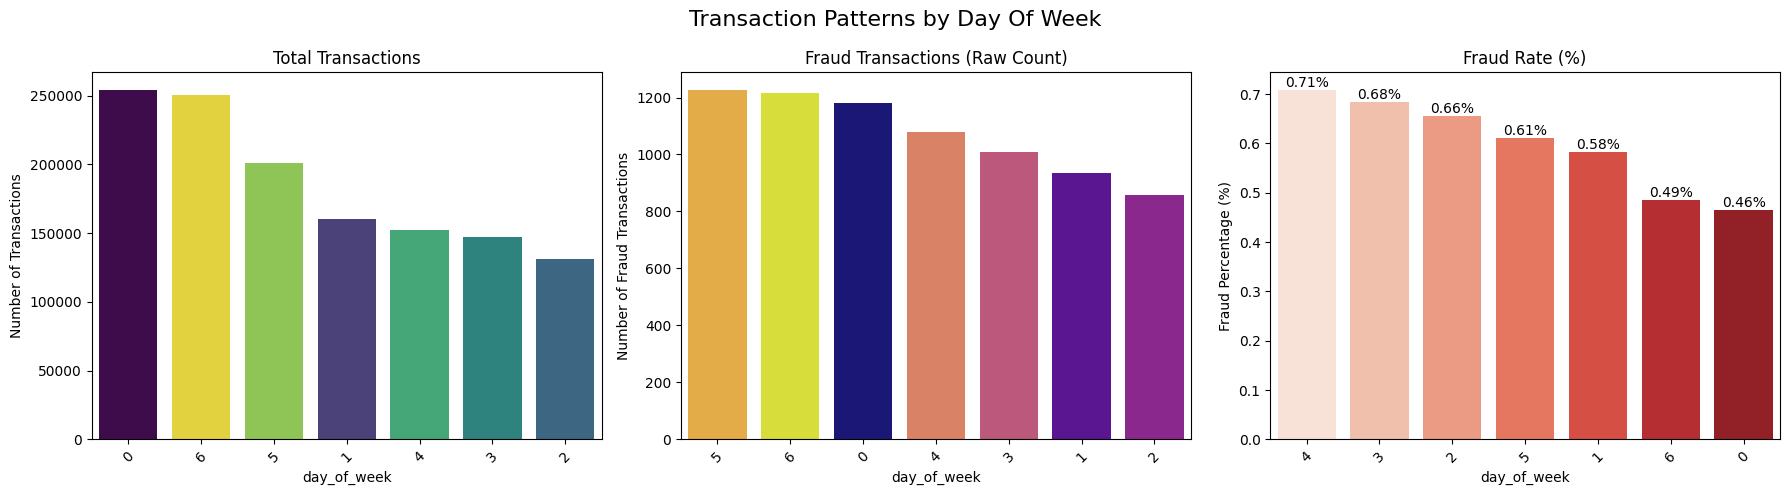

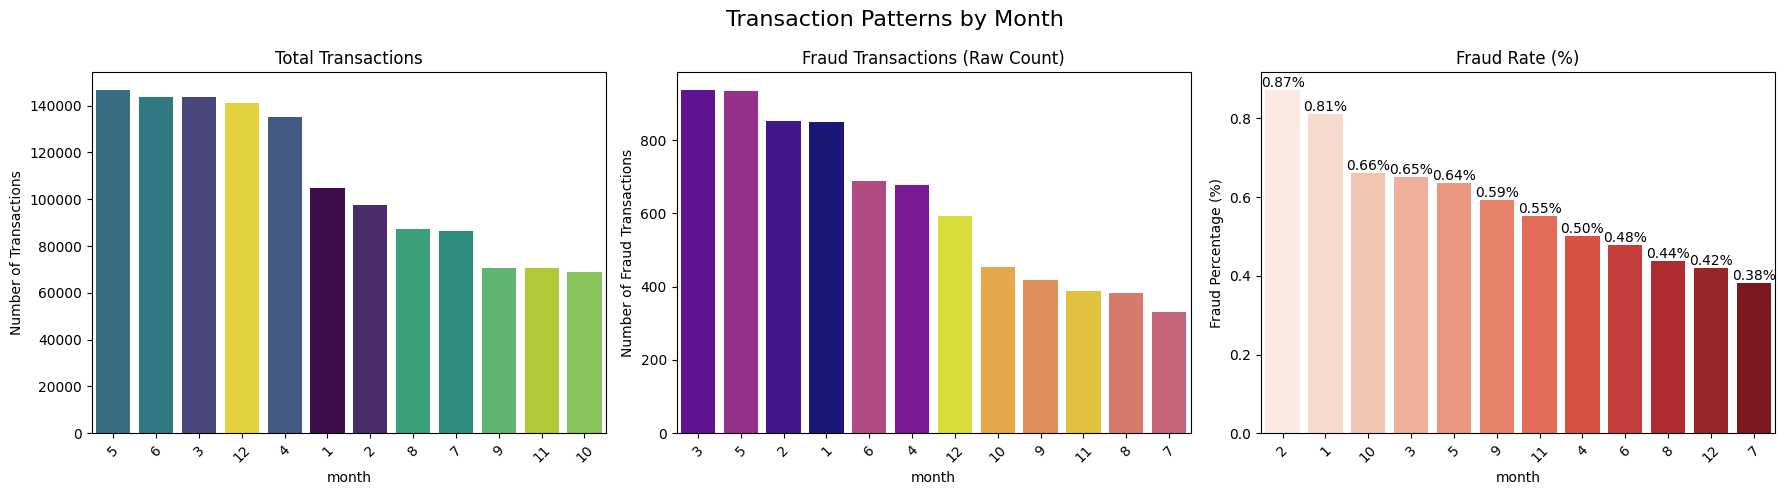

In [10]:
time_features = ['hour_of_day', 'day_of_week', 'month']

for feature in time_features:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Transaction Patterns by {feature.replace("_", " ").title()}', fontsize=16)
    
    # 1. Total Transactions (Count)
    sns.countplot(data=df, x=feature, hue=feature, palette="viridis", 
                  legend=False, ax=axes[0], order=df[feature].value_counts().index)
    axes[0].set_title('Total Transactions')
    axes[0].set_ylabel('Number of Transactions')
    axes[0].tick_params(axis='x', rotation=45)
    
    # 2. Fraud Transactions (Raw Count)
    fraud_df = df[df['is_fraud'] == 1]
    sns.countplot(data=fraud_df, x=feature, hue=feature, palette="plasma", 
                  legend=False, ax=axes[1], order=fraud_df[feature].value_counts().index)
    axes[1].set_title('Fraud Transactions (Raw Count)')
    axes[1].set_ylabel('Number of Fraud Transactions')
    axes[1].tick_params(axis='x', rotation=45)
    
    # 3. Fraud Rate (%) - Most Important View
    fraud_rate = df.groupby(feature)['is_fraud'].mean() * 100
    fraud_rate_df = fraud_rate.reset_index()
    sns.barplot(data=fraud_rate_df, x=feature, y='is_fraud', palette="Reds", ax=axes[2],
                order=fraud_rate_df.sort_values('is_fraud', ascending=False)[feature])
    axes[2].set_title('Fraud Rate (%)')
    axes[2].set_ylabel('Fraud Percentage (%)')
    axes[2].tick_params(axis='x', rotation=45)
    
    # Add value labels on fraud rate bars
    for container in axes[2].containers:
        axes[2].bar_label(container, fmt='%.2f%%')
    
    plt.tight_layout()
    plt.show()

## Key Takeaway:<br>
Time-based features (especially hour_of_day) show strong predictive power for fraud detection. Incorporating these features — particularly flagging late-night transactions — should significantly improve model performance in the subsequent modeling phase.

<br>
The analysis of temporal features reveals clear and actionable patterns in fraudulent activity:<br>

**Hour of Day**: Fraud transactions are high between 10 PM and 3 AM. The fraud rate peaks at 22:00 (2.88%) and 23:00 (2.84%), while daytime hours show very low fraud rates (<0.2%).<br>
**Day of Week**: Fraud rates are highest at the start of the week — Wednesday (0.71%) and Tuesday (0.68%) — and gradually decline toward the weekend.<br>
**Month**: A seasonal trend is visible, with the highest fraud rates in March (0.87%) and May (0.81%), steadily decreasing toward the end of the year (lowest in January at 0.38%). Early-year months appear more vulnerable.

**Correlation Matrix Heatmap**

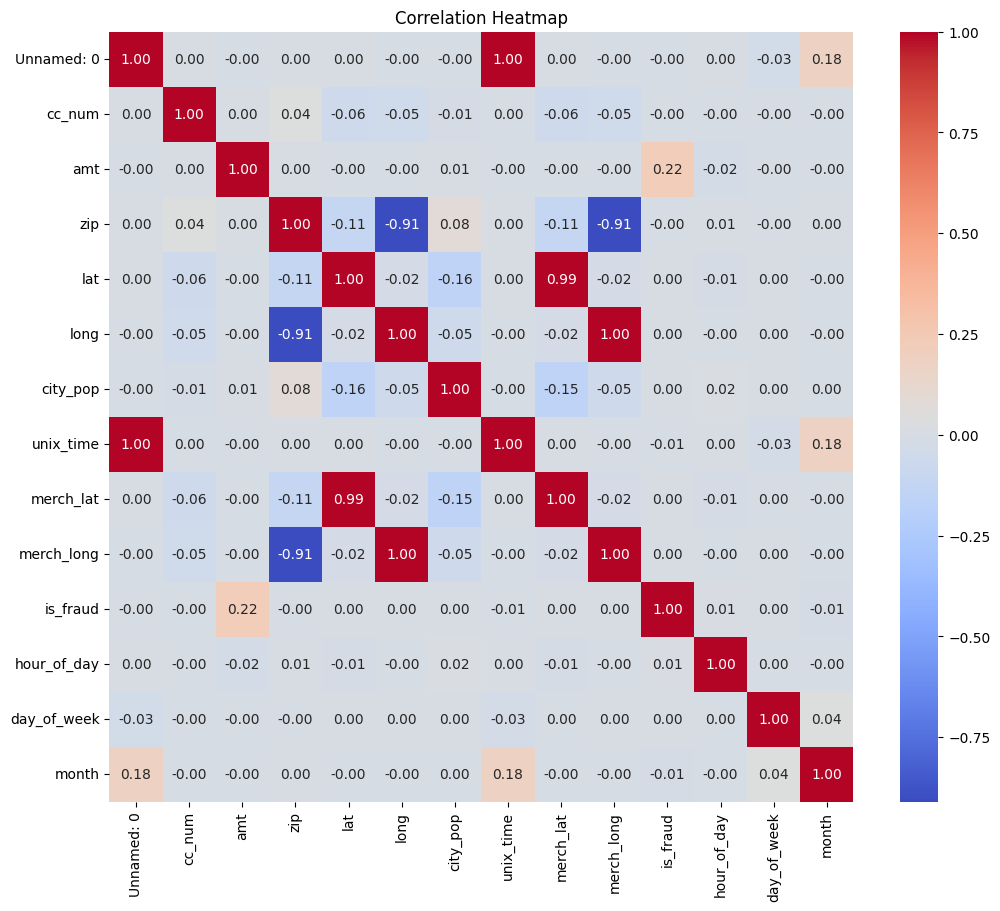

In [11]:
cor_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12,10))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**CREATE GEOGRAPHICAL DISTANCE FEATURE**

Why the Geographical Distance Feature is Extremely Important
* In this dataset, Often Fraud transactions are frequently shown in large distances.
* Most people make purchases near their home, work, or usual travel areas.
* Fraudsters (especially after stealing a card) often make transactions far away from the victim’s registered address.

In [12]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in kilometers
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# Calculate distance
df['distance_km'] = haversine(
    df['lat'], df['long'],
    df['merch_lat'], df['merch_long']
)

print(f"✅ Distance feature created!")
print(f"Mean distance: {df['distance_km'].mean():.2f} km")
print(f"Fraud vs Non-Fraud mean distance:")
print(df.groupby('is_fraud')['distance_km'].mean().round(2))

✅ Distance feature created!
Mean distance: 76.11 km
Fraud vs Non-Fraud mean distance:
is_fraud
0    76.11
1    76.27
Name: distance_km, dtype: float64


Since, mean distance are almost similar. Let's try statistical descriptions and visualizations

Distance Feature Statistics
            count   mean  median     max    std
is_fraud                                       
0         1289169  76.11   78.23  152.12  29.12
1            7506  76.27   77.93  144.52  28.75
------------------------------------------------------------


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


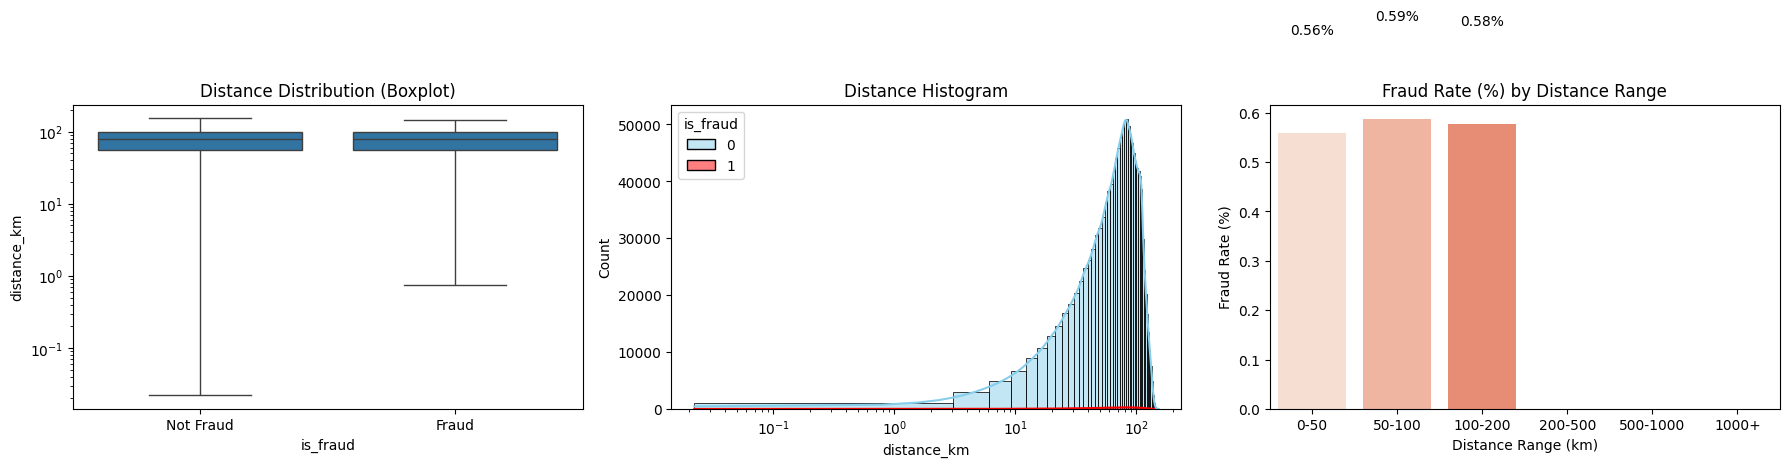

In [13]:
print("Distance Feature Statistics")
print(df.groupby('is_fraud')['distance_km'].agg(['count', 'mean', 'median', 'max', 'std']).round(2))
print("---"*20)
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Boxplot (log scale)
sns.boxplot(data=df, x='is_fraud', y='distance_km', ax=axes[0], showfliers=False)
axes[0].set_yscale('log')
axes[0].set_title('Distance Distribution (Boxplot)')
axes[0].set_xticklabels(['Not Fraud', 'Fraud'])

# 2. Histogram (focus on fraud vs non-fraud)
sns.histplot(data=df, x='distance_km', hue='is_fraud', bins=50, 
             kde=True, palette=['skyblue', 'red'], ax=axes[1])
axes[1].set_title('Distance Histogram')
axes[1].set_xscale('log')

# 3. Fraud Rate by Distance Bins
bins=[0, 50, 100, 200, 500, 1000, 5000]
labels=['0-50', '50-100', '100-200', '200-500', '500-1000', '1000+']
df['distance_bin'] = pd.cut(df['distance_km'], 
                            bins=bins, labels=labels, include_lowest=True)

fraud_rate = (df.groupby('distance_bin')['is_fraud'].mean() * 100).round(3)
sns.barplot(x=fraud_rate.index, y=fraud_rate.values, palette="Reds", ax=axes[2])
axes[2].set_title('Fraud Rate (%) by Distance Range')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].set_xlabel('Distance Range (km)')

for i, v in enumerate(fraud_rate):
    axes[2].text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.tight_layout()
plt.show()

**Conclusion**
* The 'distance_km' feature shows almost no difference between fraud and non-fraud transactions.
* Fraud rate remains nearly constant (~0.56–0.59%) across all distance ranges.<br>
→ Decision: This feature will NOT be included in modeling for now.

In [14]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'hour_of_day', 'day_of_week',
       'month', 'distance_km', 'distance_bin'],
      dtype='object')

In [15]:
df.drop(columns=["distance_bin", "Unnamed: 0", "distance_km"], inplace=True)

**SAVE CLEANED & ENGINEERED DATASET**

In [16]:
output_path = '../data/fraudTrain_prepared.csv'

df.to_csv(output_path, index=False)

print(f"✅ Saved prepared dataset with {df.shape[0]:,} rows and {df.shape[1]} columns")
print(f"File saved at: {output_path}")
print("Columns included:", df.columns.tolist())

✅ Saved prepared dataset with 1,296,675 rows and 25 columns
File saved at: ../data/fraudTrain_prepared.csv
Columns included: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'hour_of_day', 'day_of_week', 'month']


## Summary:

### Data Analysis Key Findings

*   **Missing Values**: A single row containing missing values was dropped, resulting in a clean dataset of  1296675 entries. No duplicate rows were found.
*   **Numerical Feature Distributions**:
    *   Transaction `amt` (amount) and `city_pop` (city population) are heavily right-skewed, indicating a high frequency of smaller values and a few significantly larger outliers.
    *   Geographical coordinates (`zip`, `lat`, `long`, `merch_lat`, `merch_long`) and `city_pop` show diverse distributions.
    *   `unix_time` is uniformly distributed, suggesting transactions are spread consistently over the observed period.
*   **Categorical Feature Distributions**:
    *   'gas\_transport' and 'grocery\_pos' are the most frequent transaction categories.
    *   The `gender` distribution is nearly balanced between 'M' and 'F'.
*   **Fraud Distribution**: The `is_fraud` column is highly imbalanced, with only approximately 0.58% of transactions identified as fraudulent.
*   **Time-based Transaction Patterns**: Transactions vary across `hour_of_day` and `day_of_week`. `month` data indicated transactions occurred in June; however, monthly trends are not fully observable due to the limited time frame. Fraudulent transactions also exhibit specific patterns across these time periods.
*   **Correlation Matrix**: Strong positive correlations exist between `lat` and `merch_lat`, and `long` and `merch_long`, as expected. The `is_fraud` variable shows very weak correlations with most numerical features.

### Insights or Next Steps

*   Address the severe class imbalance in the `is_fraud` column using sampling techniques (e.g., SMOTE, undersampling) or specialized algorithms during model training.
*   Utilize time-based patterns of fraudulent transactions (e.g., specific hours or days) as crucial features for developing robust fraud detection models.
